# Lesson 07c: The Rematch on Aspirin from rMD17

**What you will learn**

- Working with **rMD17**, one of the popular benchmark datasets: DFT energies
  and forces for organic molecules, its units, its official train/test splits.
  We also discuss the restrictions for using rMD17 which forbid training on more
  than 1000 of its frames.
- An apples-to-apples comparison of the same SchNet and SimpleDimeNet from
  Lessons 07a and 07b: same loss, optimizer, schedule and data budget with the
  only difference being the dataset.
- We perform an **ablation** study with angular basis truncated to a constant
  value to demonstrate that the gap in the prediction performance is caused by
  the angles themselves, not by the architecture differences.
- What triplets cost on a real molecule: from $k \approx 4$ neighbors in our
  dilute argon gas to $k \approx 15$ here: an order of magnitude more triplets
  per atom.

**Prerequisites:**

- [Lesson 07a](07a_schnet.ipynb): SchNet, forces from autograd, the training
  pipeline,
- [Lesson 07b](07b_dimenet.ipynb): `SimpleDimeNet`, triplets, and the LJ-argon
  control experiment.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import copy, time, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from e3nn import o3

from course_utils.data import load_rmd17, make_lj_argon_dataset, radius_graph
from course_utils.plotting import (plot_training_curves, scene3d,
                                    draw_point_cloud, show3d)
from course_utils.equivariance import assert_model_equivariant

warnings.filterwarnings("ignore", category=FutureWarning)  # ASE Langevin deprecation notice
torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
silu = nn.functional.silu                    # swish, DimeNet's activation (see 07b)
print(f"device = {device}, torch {torch.__version__}")

device = cuda, torch 2.7.1+cu126


## The rematch

Lesson 07b ended its training section with two notes. The first highlighted the
fact that incorporating angular features into the model adds no missing physics
for describing the Lennard-Jones potential in dilue argon gas system. Indeed the
directional model (SimpleDimeNet) brought no advantage over SchNet (a
distance-only model):

| val MAE on LJ argon | E [meV/atom] | F [meV/Å] |
|---|---|---|
| SchNet |  0.097 | 0.678 |
| SimpleDimeNet | 0.570 | 3.463 |

The second note suggested that for describing the physics of more realistic
angle-dependent systems (e.g., molecules, covalent solids, the degenerate
$\mathcal{A}^\pm$ pairs) the picture changes dramatically. We will now proceed
with training the same two models (SchNet and SimpleDimeNet) on the rMD17
dataset and see how the resulting performances change.

## The rMD17 dataset

The revised MD17 **rMD17** is a popular small-molecule benchmark dataset for
training machine-learning potentials. It is a subset of the original MD17
dataset with the following properties:

- There are ten organic molecules, each with 100 000 structures taken from the
  original MD17 molecular-dynamics trajectories (Chmiela et al. 2017) at 500 K.

- The energies and forces are **recomputed** at the PBE/def2-SVP level with very
  tight SCF convergence and dense integration grids, making the labels
  practically free of numerical noise. (The original MD17 labels carry noise of
  roughly the size of the errors of a good model which is a serious problem when
  training models *on forces*.)

- Because the structures come from an MD trajectory, they are a **correlated
  time series**, not independent samples. The dataset's own readme file states:
  *"DO NOT train a model on more than 1000 samples from this dataset."* The
  authors provide official 1000-train/1000-test index splits. We use their
  **split 01** and stay well below the cap.

- The units are kcal/mol and Å. Our loader function converts to the course units,
  eV and Å (1 kcal/mol = 43.36 meV).

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The <code>course_utils.data.load_rmd17</code> module downloads the
data artifacts once ($\approx$ 150 MB), keeps the 2000 frames of the official
split in a small ($\approx$ 2 MB) local cache under <code>artifacts/</code>,
deletes the big downloaded artifacts, and works offline afterwards.
</div>

Our molecule is **aspirin**, C$_9$H$_8$O$_4$, 21 atoms which is objectively, the
hardest case of the ten molecules with an aromatic ring, an ester and a
carboxylic acid, connected by rotatable bonds. Thus, the system involves bends,
torsions and conjugation in it, making its energy a function of angles. We
proceed with the exact same data budget of Lessons 07a/07b: **150 training and
50 validation frames**.

In [2]:
# Load the aspirin rMD17 dataset, and prepare the species map for the embeddings
train_frames, val_frames, z = load_rmd17("aspirin", n_train=150, n_val=50)

# Three elements in the data
# We map nuclear charge Z to a species index 0, 1, 2 for the embeddings
# {1:0, 6:1, 8:2}
species_map = {int(Z): s for s, Z in enumerate(torch.unique(z).tolist())}
species = torch.tensor([species_map[int(Z)] for Z in z])

# Count the number of species and atoms for later use
n_species, n_atoms = len(species_map), len(z)

# The common cutoff choice for the MD17 molecules (in Å)
R_CUT = 5.0

# Get the per-atom mean energy shift and the force standard deviation for the
# aspirin dataset
E_train = np.array([f["energy"] for f in train_frames])
eps_bar = E_train.mean() / n_atoms
F_std = torch.stack([f["forces"] for f in train_frames]).std()

# Print some statistics about the aspirin dataset
print(f"aspirin: {n_atoms} atoms, species map {species_map} (H, C, O)")
print(f"{len(train_frames)} train / {len(val_frames)} val frames (official rMD17 split 01)")
print(f"E fluctuations: std = {E_train.std()*1e3:.1f} meV  |  F std = {F_std*1e3:.1f} meV/Å")
print("compare LJ argon (07a):  E std =  21.3 meV  |  F std =   32.4 meV/Å")

aspirin: 21 atoms, species map {1: 0, 6: 1, 8: 2} (H, C, O)
150 train / 50 val frames (official rMD17 split 01)
E fluctuations: std = 269.4 meV  |  F std = 1273.3 meV/Å
compare LJ argon (07a):  E std =  21.3 meV  |  F std =   32.4 meV/Å


Comparing the force scale between aspirin and argon shows two very different
worlds: The force components in aspirin have standard deviation of $\approx$ 1.3
eV/Å instead of argon's $\approx$ 32 meV/Å. Covalent bonds are similar to stiff
springs which produce large forces when stretched or compressed.

<div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;"> 

<b>Note:</b> The covalent skeleton (only bond-length pairs, $d < 1.8$ Å), and
the radius graph the models actually consume at $r_\mathrm{cut} = 5$ Å.
Aspirin's diameter is only $\approx$ 8 Å, so the model graph connects most
pairs. So, the "dilute" regime of Lesson 07a does not exist here.
</div>

In [3]:
# Get the first training frame's positions
pos0 = train_frames[0]["pos"]

# Compute the radius graph for the covalent skeleton
# (bond-length pairs, d < 1.8 Å)
bonds = radius_graph(pos0, 1.8)

# Compute the radius graph for the model's cutoff
# (What SchNet / DimeNet actually see)
graph = radius_graph(pos0, R_CUT)

# Visualize the covalent skeleton and the model graph
fig = scene3d(1, 2, titles=[f"covalent skeleton ({bonds.shape[1]} directed edges)",
                            f"model graph, r_cut = {R_CUT} Å ({graph.shape[1]} directed edges)"],
              title_dy=-0.05)

# Draw the point cloud for the two graphs, coloring by element
elements = {1: ("H", "silver", 5), 6: ("C", "dimgray", 8), 8: ("O", "red", 8)}

for panel, edges in enumerate([bonds, graph]):
    draw_point_cloud(pos0, fig=fig, cell=(1, panel + 1), size=1, color="lightgray",
                     edges=edges)
    for Z_el, (name, color, size) in elements.items():
        draw_point_cloud(pos0[z == Z_el], fig=fig, cell=(1, panel + 1), color=color,
                         size=size, label=name if panel == 0 else None)
show3d(fig)

<plotly figure: interactive 3D scene>

## Changes between the rMD17 and argon datasets

### The physics

Recall the classical force-field energy decomposition presented at the start of
Lesson 07b:

$$
E = E_\text{bonds} + E_\text{angle} + E_\text{torsion} + E_\text{non-bonding}.
$$

For the LJ argon, only the last term exists. For aspirin, the angle and torsion
terms are where the interesting chemistry happens. These are exactly the terms
that the WL argument of Lesson 07b focuses on and states that a distance-based
GNN cannot represent *directly* (it can only reconstruct them implicitly from
patterns of overlapping distances, which demands additional data and depth).

### The geometry

We use $r_\mathrm{cut} = 5$ Å, which is a common choice for the MD17 molecules
in the interatomic-potential literature. The cutoff radius is chosen to include
all significant interactions while keeping the computational cost manageable.
With this choice, the mean number of neighbors, $k$, jumps by a factor of
$\approx$ 4 relative to our dilute argon gas and the triplet count, which scales
as $O(Nk^2)$ (Lesson 07b), by far more. 

Let's take one frame from the argon and aspirin subsets and count the number of
neighbors and triplets, noting that

$$
\#\text{triplets} = \sum_j \deg(j)\,(\deg(j) - 1)
$$

In [4]:
# Get the positions of a single frame of LJ argon for comparison
argon_pos = make_lj_argon_dataset(n_frames=1)[0]["pos"]

# Print the table header
print(f"{'system':>17} | {'atoms':>5} | {'edges':>5} | {'k':>5} | {'triplets':>8} | {'trips/atom':>8}")

# Compute the radius graph and the number of triplets for both LJ argon and aspirin
for name, p, rc in [("LJ argon", argon_pos, 6.0), ("rMD17 aspirin", pos0, R_CUT)]:
    
    # Compute the radius graph for the given positions and cutoff
    ei = radius_graph(p, rc)
    
    # Neighbors within the cutoff
    deg = torch.bincount(ei[0], minlength=len(p))
    
    # sum_j deg(j)(deg(j)-1)
    n_trip = int((deg * (deg - 1)).sum())
    
    print(f"{name:>17} | {len(p):>5} | {ei.shape[1]:>5} | {ei.shape[1]/len(p):>5.1f} "
          f"| {n_trip:>8} | {n_trip/len(p):>10.1f}")

           system | atoms | edges |     k | triplets | trips/atom
         LJ argon |     8 |    30 |   3.8 |       96 |       12.0
    rMD17 aspirin |    21 |   294 |  14.0 |     4054 |      193.0


## The contenders

Both SchNet and DimeNet models are re-implemented, word-by-word, from their home
lessons: every line is derived and explained there ([Lesson
07a](07a_schnet.ipynb) for SchNet, [Lesson07b](07b_dimenet.ipynb) for
SimpleDimeNet). Here, they are just compressed into one cell each. 

Before we proceed with training, note that:

- **The species embedding represents more information:** Lesson 07a used the
  `nn.Embedding(n_species, F)` module with a single species. In comparison,
  aspirin has three elements. Thus, the model uses `n_species = 3` and the
  embedding now conveys more chemical information.

- **The angular model is the *smaller* one:** The SimpleDimeNet model has fewer
  parameters than the SchNet model. Specifically, the SimpleDimeNet model has
  approximately 51 k parameters, while the SchNet model has approximately 59 k
  parameters.

In [5]:
####################################
# SchNet (from Lesson 07a)
####################################

# Shifted softplus, ssp(0) = 0
def ssp(x):
    return nn.functional.softplus(x) - np.log(2.0)

class GaussianRBF(nn.Module):
    '''e_k(d) = exp(-gamma (d - mu_k)^2) on a regular grid of centers mu_k.'''
    
    def __init__(self, r_cut: float, n_rbf: int = 32, gamma: float = 10.0):
        super().__init__()
        self.register_buffer("mu", torch.linspace(0.0, r_cut, n_rbf))
        self.gamma = gamma
    
    # (E,) -> (E, n_rbf)
    def forward(self, d):
        return torch.exp(-self.gamma * (d.unsqueeze(-1) - self.mu) ** 2)

class FilterNet(nn.Module):
    '''W(d): RBF expansion -> two dense layers -> smooth cosine cutoff (Lesson 05b).'''
    
    def __init__(self, n_features: int, r_cut: float, n_rbf: int = 32):
        super().__init__()
        self.rbf = GaussianRBF(r_cut, n_rbf)
        self.dense1 = nn.Linear(n_rbf, n_features)
        self.dense2 = nn.Linear(n_features, n_features)
        self.r_cut = r_cut
    
    def forward(self, d):
        W = ssp(self.dense2(ssp(self.dense1(self.rbf(d)))))
        f_cut = 0.5 * (torch.cos(np.pi * d / self.r_cut) + 1.0)
        return W * f_cut.unsqueeze(-1)

class CFConv(nn.Module):
    '''Continuous-filter convolution:  x_i' = sum_{j in N(i)} x_j (*) W(d_ij).'''
    
    def __init__(self, n_features: int, r_cut: float):
        super().__init__()
        self.filter_net = FilterNet(n_features, r_cut)
        
    def forward(self, x, edge_index, d):
        # Receiver i, sender j (Lesson 05a)
        i, j = edge_index
        messages = x[j] * self.filter_net(d)
        return torch.zeros_like(x).index_add_(0, i, messages)

class InteractionBlock(nn.Module):
    '''x_i <- x_i + aw3( ssp( aw2( cfconv( aw1(x) ) ) ) )'''
    
    def __init__(self, n_features: int, r_cut: float):
        super().__init__()
        self.aw1 = nn.Linear(n_features, n_features)
        self.cfconv = CFConv(n_features, r_cut)
        self.aw2 = nn.Linear(n_features, n_features)
        self.aw3 = nn.Linear(n_features, n_features)
        
    def forward(self, x, edge_index, d):
        return x + self.aw3(ssp(self.aw2(self.cfconv(self.aw1(x), edge_index, d))))

class SchNet(nn.Module):
    '''Embedding -> T interaction blocks -> atom-wise readout, sum-pooled (07a).'''
    
    def __init__(self, n_features: int = 64, n_interactions: int = 3,
                 r_cut: float = 6.0, n_species: int = 1):
        super().__init__()
        self.embedding = nn.Embedding(n_species, n_features)
        self.interactions = nn.ModuleList(
            [InteractionBlock(n_features, r_cut) for _ in range(n_interactions)])
        self.readout1 = nn.Linear(n_features, n_features // 2)
        self.readout2 = nn.Linear(n_features // 2, 1)
        self.r_cut = r_cut
        
    def forward(self, pos, species, edge_index, batch, n_graphs):
        i, j = edge_index
        d = (pos[j] - pos[i]).norm(dim=-1)
        x = self.embedding(species)
        for block in self.interactions:
            x = block(x, edge_index, d)
        E_i = self.readout2(ssp(self.readout1(x))).squeeze(-1)
        E = torch.zeros(n_graphs, dtype=pos.dtype, device=pos.device)
        return E.index_add_(0, batch, E_i)

In [6]:
####################################
# SimpleDimeNet and its helpers
# (from Lesson 07b)
####################################

class BesselRBF(nn.Module):
    '''e_n(d) = u(d/c) sqrt(2/c) sin(n pi d / c) / d    (07b Eqs. (7) + (8), p = 6).'''
    
    def __init__(self, r_cut: float, n_rbf: int = 8, p: int = 6):
        super().__init__()
        self.register_buffer("n", torch.arange(1, n_rbf + 1, dtype=torch.get_default_dtype()))
        self.r_cut, self.p = r_cut, p
        
    def envelope(self, x):
        p = self.p
        return (1 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
                - p * (p + 1) / 2 * x**(p + 2))
        
    def forward(self, d):
        x = (d / self.r_cut).unsqueeze(-1)
        e = np.sqrt(2.0 / self.r_cut) * torch.sin(self.n * np.pi * x) / d.unsqueeze(-1)
        return e * self.envelope(x)

def cos_basis(cos_alpha, n_ang: int):
    '''[1, cos a, cos 2a, ...] via the Chebyshev recursion (no arccos, see Lesson 07b).'''
    
    T = [torch.ones_like(cos_alpha), cos_alpha]
    for _ in range(n_ang - 2):
        T.append(2 * cos_alpha * T[-1] - T[-2])
    return torch.stack(T[:n_ang], dim=-1)

def find_triplets(edge_index):
    '''All edge pairs (a: k->j, b: j->i) with k != i, as indices into the edge list.'''
    
    recv, send = edge_index
    match = recv.unsqueeze(1) == send.unsqueeze(0)
    not_backtrack = send.unsqueeze(1) != recv.unsqueeze(0)
    a_idx, b_idx = (match & not_backtrack).nonzero(as_tuple=True)
    return a_idx, b_idx

class DirectionalInteraction(nn.Module):
    '''07b Eq. (4) with the DimeNet++-style Hadamard interaction.'''
    
    def __init__(self, F: int, n_rbf: int, n_ang: int):
        super().__init__()
        self.W_e = nn.Linear(n_rbf, F, bias=False)
        self.W_a = nn.Linear(n_rbf * n_ang, F, bias=False)
        self.W_m = nn.Linear(F, F)
        self.W_1 = nn.Linear(2 * F, F)
        self.W_2 = nn.Linear(F, F)
        
    def forward(self, m, e, a, trip_a, trip_b):
        t = self.W_e(e)[trip_b] * self.W_a(a) * silu(self.W_m(m[trip_a]))
        s = torch.zeros_like(m).index_add_(0, trip_b, t)
        return m + silu(self.W_2(silu(self.W_1(torch.cat([m, s], dim=-1)))))

class SimpleDimeNet(nn.Module):
    '''Directed-edge embeddings + directional message passing (Lesson07b, simplified).'''
    
    def __init__(self, n_features=64, n_blocks=2, r_cut=6.0, n_rbf=8, n_ang=6, n_species=1):
        super().__init__()
        self.rbf = BesselRBF(r_cut, n_rbf)
        self.embedding = nn.Embedding(n_species, n_features)
        self.edge_embed = nn.Linear(2 * n_features + n_rbf, n_features)
        self.blocks = nn.ModuleList(
            [DirectionalInteraction(n_features, n_rbf, n_ang) for _ in range(n_blocks)])
        self.readout1 = nn.Linear(n_features, n_features // 2)
        self.readout2 = nn.Linear(n_features // 2, 1)
        self.n_ang = n_ang
        
    def forward(self, pos, species, edge_index, trip_a, trip_b, batch, n_graphs):
        recv, send = edge_index
        d = (pos[send] - pos[recv]).norm(dim=-1)
        e = self.rbf(d)
        h = self.embedding(species)
        m = silu(self.edge_embed(torch.cat([h[send], h[recv], e], dim=-1)))
        # x_k - x_j
        u = pos[send[trip_a]] - pos[recv[trip_a]]
        # x_i - x_j
        v = pos[recv[trip_b]] - pos[send[trip_b]]
        cos_alpha = (u * v).sum(-1) / (u.norm(dim=-1) * v.norm(dim=-1))
        a = (self.rbf(u.norm(dim=-1)).unsqueeze(-1)
             * cos_basis(cos_alpha, self.n_ang).unsqueeze(-2)).flatten(-2)
        for block in self.blocks:
            m = block(m, e, a, trip_a, trip_b)
        # h_i = sum_j m_ji
        h_i = torch.zeros(len(pos), m.shape[-1], dtype=pos.dtype,
                          device=pos.device).index_add_(0, recv, m)
        E_i = self.readout2(silu(self.readout1(h_i))).squeeze(-1)
        E = torch.zeros(n_graphs, dtype=pos.dtype, device=pos.device)
        return E.index_add_(0, batch, E_i)

## From full batch to mini-batches

One important change is necessary in the data preprocessing pipeline. The argon
lessons trained the models on a **full-batch** of data: 150 frames of 8 atoms
made a single graph of 1200 atoms and $\approx$ 4000 edges. The same 150 frames
of aspirin make $\approx$ 45,000 edges and $\approx$ 640,000 triplets, and
training on forces backpropagates *through* the triplet tensor twice
(`create_graph=True`). 

This amount of data still fits on a GPU, but it is wasteful: one parameter
update per epoch is a bad exchange rate for that much compute. We instead split
the training set into **mini-batches of 25 frames** (six updates per epoch). The
geometries are static, so all graphs and triplet lists are still precomputed
once. 

Again, we use the `make_batch` helper from  Lesson 07b but with the species
tensor now carrying real element indices.

In [7]:
# Set the batch size for training and validation
BATCH = 25

# Create mini-batches of training and validation data
def make_batch(frame_list, device):
    '''One disconnected graph: pos, species, edges, triplets, batch, E~, F  (as in 07b).'''
    
    pos, spec, edges, batch, E, F = [], [], [], [], [], []
    offset = 0
    for g, f in enumerate(frame_list):
        
        # Get the positions and append to the lists
        p = f["pos"].float()
        pos.append(p)
        
        # H/C/O indices, same for every frame
        spec.append(species)
        
        # Create the radius graph and append to the lists
        edges.append(radius_graph(p, R_CUT) + offset)
        
        # Create the batch index and append to the lists
        batch.append(torch.full((len(p),), g, dtype=torch.long))
        
        # Append the energy and forces to the lists
        E.append(f["energy"] - len(p) * eps_bar)
        F.append(f["forces"].float())
        
        # Update the offset for the next frame
        offset += len(p)
    
    # Concatenate the edges and find the triplets for the entire batch
    edge_index = torch.cat(edges, dim=1)
    # Precomputed once (static geometry)
    trip_a, trip_b = find_triplets(edge_index)
    
    # Return the concatenated tensors and move them to the specified device
    return (torch.cat(pos).to(device), torch.cat(spec).to(device),
            edge_index.to(device), trip_a.to(device), trip_b.to(device),
            torch.cat(batch).to(device),
            torch.tensor(E, dtype=torch.float32, device=device), torch.cat(F).to(device))

# Create mini-batches of training and validation data
train_batches = [make_batch(train_frames[i:i + BATCH], device)
                 for i in range(0, len(train_frames), BATCH)]
val_batch = make_batch(val_frames, device)

# Print the number of mini-batches, edges, and triplets in the training set
n_edges = sum(b[2].shape[1] for b in train_batches)
n_trips = sum(len(b[3]) for b in train_batches)
print(f"{len(train_batches)} mini-batches of {BATCH} frames | "
      f"train set total: {n_edges} edges, {n_trips} triplets "
      f"({n_trips / (len(train_frames) * n_atoms):.0f} per atom)")

6 mini-batches of 25 frames | train set total: 45402 edges, 642690 triplets (204 per atom)


## Training protocol

We use the same training protocol for all models in this lesson. We adopt
SchNet's loss function with $\rho = 1$, Adam optimizer with a learning rate of
$3\times10^{-3}$, cosine annealing, and train for 600 epochs. We compute forces
using autograd: every knob is exactly the same as those in Lessons 07a and 07b
and the *only* experimental variable is the dataset. 

Two important notes:

- After the per-atom mean shift, aspirin's energy fluctuations ($\approx$ 13
  meV/atom) are much smaller than its force components ($\approx$ 1.3 eV/Å). As
  such, with $\rho = 1$ the force term dominates the loss. That is standard
  practice for interatomic potentials as each frame carries $3n = 63$ force
  labels against one energy label, and forces are what molecular dynamics
  consumes. Nonetheless, this means that the energy MAE rides along rather than
  being optimized hard.

- With a single fixed composition, the per-atom mean shift is just a constant
  offset. For datasets that mix molecules of different composition, the standard
  generalization is a least-squares fit of per-*element* reference energies. We
  will not, however, need it here.

Below, we implement one helper function (i.e., `energy_and_forces`) which routes
each architecture's inputs (SchNet consumes no triplets). So, a single training
loop serves every model in this lesson:

In [8]:
# Helper functions to compute energy and forces based on the model
def energy_and_forces(model, batch, create_graph=False):
    '''E and F = -dE/dpos for either architecture (Lesson 07a).'''
    
    pos, spec, edge_index, trip_a, trip_b, bvec, E_ref, F_ref = batch
    pos = pos.requires_grad_(True)
    if isinstance(model, SimpleDimeNet):
        E = model(pos, spec, edge_index, trip_a, trip_b, bvec, len(E_ref))
    else:
        # SchNet: no triplets needed
        E = model(pos, spec, edge_index, bvec, len(E_ref))
    (dE_dpos,) = torch.autograd.grad(E.sum(), pos, create_graph=create_graph)
    return E, -dE_dpos

# Compute the mean absolute error (MAE) for energy and forces on a batch
def eval_mae(model, batch):
    '''(energy MAE [meV/atom], force MAE [meV/Å]) on one batch.'''
    
    E, F = energy_and_forces(model, batch)
    return ((E - batch[6]).abs().mean().item() / n_atoms * 1e3,
            (F - batch[7]).abs().mean().item() * 1e3)

# Compute the loss function for energy and forces, with optional weighting
def loss_fn(E, F, E_ref, F_ref, rho=1.0):
    return rho * ((E_ref - E) ** 2).mean() + ((F_ref - F) ** 2).sum(dim=-1).mean()

# Train the model for a specified number of epochs
def train(model, label, n_epochs=600, lr=3e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    history = {"train E MAE [meV/atom]": [], "val E MAE [meV/atom]": [],
               "train F MAE [meV/Å]": [], "val F MAE [meV/Å]": []}
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        for b in train_batches:
            optimizer.zero_grad()
            E, F = energy_and_forces(model, b, create_graph=True)
            loss_fn(E, F, b[6], b[7]).backward()
            optimizer.step()
        scheduler.step()
        tr = eval_mae(model, train_batches[0])           # first mini-batch as train proxy
        va = eval_mae(model, val_batch)
        for key, v in zip(history, (tr[0], va[0], tr[1], va[1])):
            history[key].append(v)
        if epoch % 100 == 0 or epoch == n_epochs - 1:
            print(f"[{label}] epoch {epoch:4d}   val E MAE {va[0]:7.3f} meV/atom   "
                  f"val F MAE {va[1]:8.2f} meV/Å")
    dt = time.time() - t0
    print(f"[{label}] training time: {dt:.0f} s on {device}")
    return history, dt

First, let's train the distance-only model, SchNet. (Each of the three training
cells in this lesson takes about a minute on an A100 GPU. Expect several minutes
for each on CPU.)

In [9]:
# Set the random seed for reproducibility
torch.manual_seed(0)

# Initialize the SchNet model and print the number of parameters
schnet = SchNet(r_cut=R_CUT, n_species=n_species).to(device)
print("SchNet parameters:", sum(p.numel() for p in schnet.parameters()))

# Train the SchNet model and record the training history and time
hist_schnet, t_schnet = train(schnet, "SchNet")

SchNet parameters: 58561
[SchNet] epoch    0   val E MAE  20.866 meV/atom   val F MAE   934.93 meV/Å
[SchNet] epoch  100   val E MAE   7.784 meV/atom   val F MAE   225.97 meV/Å
[SchNet] epoch  200   val E MAE   3.139 meV/atom   val F MAE   181.00 meV/Å
[SchNet] epoch  300   val E MAE   2.849 meV/atom   val F MAE   154.51 meV/Å
[SchNet] epoch  400   val E MAE   2.586 meV/atom   val F MAE   137.39 meV/Å
[SchNet] epoch  500   val E MAE   2.740 meV/atom   val F MAE   130.72 meV/Å
[SchNet] epoch  599   val E MAE   2.362 meV/atom   val F MAE   129.51 meV/Å
[SchNet] training time: 66 s on cuda


It's time to train our directional model, SimpleDimeNet on same data and with
the same budget:

In [10]:
# Set the random seed for reproducibility
torch.manual_seed(0)

# Initialize the SimpleDimeNet model and print the number of parameters
dimenet = SimpleDimeNet(r_cut=R_CUT, n_species=n_species).to(device)
print("SimpleDimeNet parameters:", sum(p.numel() for p in dimenet.parameters()))

# Train the SimpleDimeNet model and record the training history and time
hist_dimenet, t_dimenet = train(dimenet, "SimpleDimeNet")

SimpleDimeNet parameters: 51393
[SimpleDimeNet] epoch    0   val E MAE 478.649 meV/atom   val F MAE   938.10 meV/Å
[SimpleDimeNet] epoch  100   val E MAE   4.554 meV/atom   val F MAE   162.93 meV/Å
[SimpleDimeNet] epoch  200   val E MAE   4.031 meV/atom   val F MAE   130.96 meV/Å
[SimpleDimeNet] epoch  300   val E MAE   2.264 meV/atom   val F MAE   110.70 meV/Å
[SimpleDimeNet] epoch  400   val E MAE   2.065 meV/atom   val F MAE   102.01 meV/Å
[SimpleDimeNet] epoch  500   val E MAE   2.091 meV/atom   val F MAE    98.30 meV/Å
[SimpleDimeNet] epoch  599   val E MAE   2.012 meV/atom   val F MAE    97.77 meV/Å
[SimpleDimeNet] training time: 81 s on cuda


## Results

Let us now have the previous results on the argon dataset (from Lesson 07b)
alongside the new aspirin results.:

In [11]:
# Set both models to evaluation mode
schnet.eval()
dimenet.eval()

# Evaluate the mean absolute error (MAE) for energy and forces on the validation
# batch for both models
e_s, f_s = eval_mae(schnet, val_batch)
e_d, f_d = eval_mae(dimenet, val_batch)

# Print the results on the aspirin dataset in a formatted table
print(f"{'val MAE':>22} | {'E [meV/atom]':>13} | {'F [meV/Å]':>10} | {'s/epoch':>8}")
print(f"{'SchNet (07a)':>22} | {e_s:>13.2f} | {f_s:>10.2f} | {t_schnet/600:>8.2f}")
print(f"{'SimpleDimeNet (07b)':>22} | {e_d:>13.2f} | {f_d:>10.2f} | {t_dimenet/600:>8.2f}")

# Print the force errors on both the LJ argon and aspirin datasets for comparison
print(f"\nforce MAE [meV/Å]{'':>6} | {'SchNet':>8} | {'SimpleDimeNet':>13}")
print(f"{'LJ argon (07b table)':>22} | {0.678:>8.3f} | {3.463:>13.3f}   <- distances suffice")
print(f"{'rMD17 aspirin':>22} | {f_s:>8.1f} | {f_d:>13.1f}   "
      f"<- angles matter ({f_s/f_d:.1f}x)")

               val MAE |  E [meV/atom] |  F [meV/Å] |  s/epoch
          SchNet (07a) |          2.36 |     129.51 |     0.11
   SimpleDimeNet (07b) |          2.01 |      97.77 |     0.13

force MAE [meV/Å]       |   SchNet | SimpleDimeNet
  LJ argon (07b table) |    0.678 |         3.463   <- distances suffice
         rMD17 aspirin |    129.5 |          97.8   <- angles matter (1.3x)


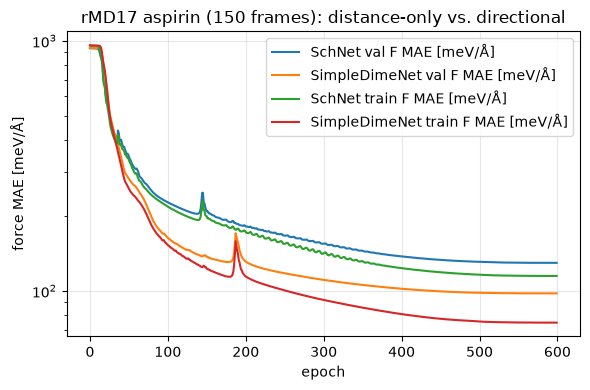

In [12]:
# Plot the training curves for both models
ax = plot_training_curves({
    "SchNet val F MAE [meV/Å]": hist_schnet["val F MAE [meV/Å]"],
    "SimpleDimeNet val F MAE [meV/Å]": hist_dimenet["val F MAE [meV/Å]"],
    "SchNet train F MAE [meV/Å]": hist_schnet["train F MAE [meV/Å]"],
    "SimpleDimeNet train F MAE [meV/Å]": hist_dimenet["train F MAE [meV/Å]"],
})
ax.set_ylabel("force MAE [meV/Å]")
ax.set_title("rMD17 aspirin (150 frames): distance-only vs. directional")
ax.figure.tight_layout()

Looking at the training curves, we can see that the performance gap between the
two models opens within the first hundred epochs. Each model's training curve
tracks its validation curve: the advantage shows up on unseen frames, not
through memorization and overfitting. 

Let us now look at the parity plots for forces using both models.

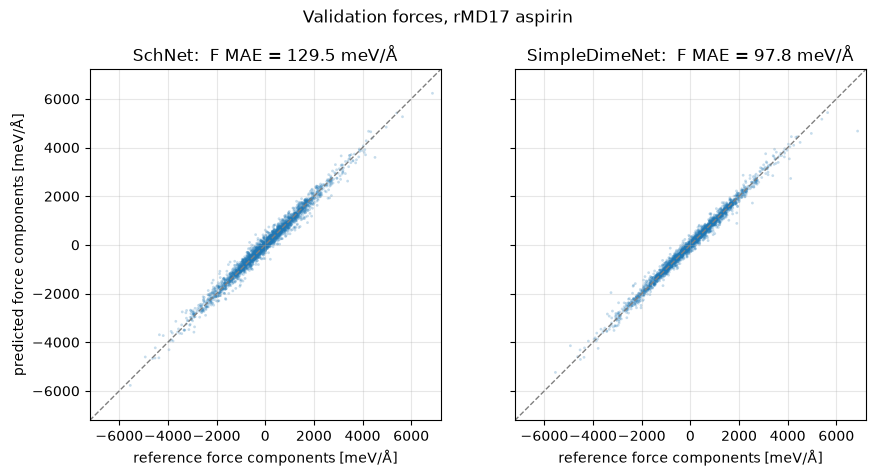

In [13]:
# Plot the predicted vs. reference forces for both models on the validation batch
F_true = val_batch[7].cpu().numpy().ravel() * 1e3

# Create a 1x2 subplot for the force comparison
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.6), sharex=True, sharey=True)
lim = np.abs(F_true).max() * 1.05
for ax, model, (label, f_mae) in zip(axes, [schnet, dimenet],
                                     [("SchNet", f_s), ("SimpleDimeNet", f_d)]):
    _, F_val = energy_and_forces(model, val_batch)
    F_pred = F_val.detach().cpu().numpy().ravel() * 1e3
    ax.plot([-lim, lim], [-lim, lim], "--", color="gray", lw=1)
    ax.scatter(F_true, F_pred, s=4, alpha=0.25, color="C0", edgecolors="none")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("reference force components [meV/Å]")
    ax.set_title(f"{label}:  F MAE = {f_mae:.1f} meV/Å")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("predicted force components [meV/Å]")
fig.suptitle("Validation forces, rMD17 aspirin", y=1.0)
fig.tight_layout()

## Is it really the angles?

The two architectures differ in more than just incorporating angles. They use
different radial bases, edge instead of atom embeddings, and different
activations. To pin down the gap due to the angles themselves, we run an
ablation experiment from Lesson 07b's Exercise 2 as a first-class case study
here. To do so, we set `n_ang = 1`, so that the angular basis collapses to the
constant $T_0 = 1$. The resulting model still builds and pays for computing
every triplet, still uses Bessel bases, edge embeddings and swish activation,
but it just cannot *resolve* the angles between the edges.

In [14]:
# Set the random seed for reproducibility
torch.manual_seed(0)

# Initialize the angle-blind SimpleDimeNet model (n_ang=1) and print the number
# of parameters
dimenet_noang = SimpleDimeNet(r_cut=R_CUT, n_species=n_species, n_ang=1).to(device)
print("angle-blind SimpleDimeNet parameters:",
      sum(p.numel() for p in dimenet_noang.parameters()))

# Train the angle-blind SimpleDimeNet model and record the training history and
# time
hist_noang, t_noang = train(dimenet_noang, "SimpleDimeNet, n_ang=1")

angle-blind SimpleDimeNet parameters: 46273
[SimpleDimeNet, n_ang=1] epoch    0   val E MAE  71.136 meV/atom   val F MAE   936.37 meV/Å
[SimpleDimeNet, n_ang=1] epoch  100   val E MAE  10.074 meV/atom   val F MAE   271.18 meV/Å
[SimpleDimeNet, n_ang=1] epoch  200   val E MAE  12.068 meV/atom   val F MAE   214.66 meV/Å
[SimpleDimeNet, n_ang=1] epoch  300   val E MAE   4.643 meV/atom   val F MAE   186.17 meV/Å
[SimpleDimeNet, n_ang=1] epoch  400   val E MAE   4.071 meV/atom   val F MAE   173.46 meV/Å
[SimpleDimeNet, n_ang=1] epoch  500   val E MAE   7.565 meV/atom   val F MAE   168.16 meV/Å
[SimpleDimeNet, n_ang=1] epoch  599   val E MAE   3.866 meV/atom   val F MAE   167.43 meV/Å
[SimpleDimeNet, n_ang=1] training time: 65 s on cuda


After finishing the training, we can see how the angle-blind SimpleDimeNet model
performs on the validation set

In [15]:
# Set the angle-blind SimpleDimeNet model to evaluation mode
dimenet_noang.eval()

# Evaluate the mean absolute error (MAE) for energy and forces on the validation
# batch for the angle-blind SimpleDimeNet model
e_n, f_n = eval_mae(dimenet_noang, val_batch)

# Print the results on the aspirin dataset in a formatted table, including the
# angle-blind SimpleDimeNet model
print(f"{'val MAE':>28} | {'E [meV/atom]':>13} | {'F [meV/Å]':>10}")
print(f"{'SchNet (Lesson 07a)':>28} | {e_s:>13.2f} | {f_s:>10.2f}")
print(f"{'SimpleDimeNet':>28} | {e_d:>13.2f} | {f_d:>10.2f}")
print(f"{'SimpleDimeNet, n_ang=1':>28} | {e_n:>13.2f} | {f_n:>10.2f}   <- angle-blind")

                     val MAE |  E [meV/atom] |  F [meV/Å]
         SchNet (Lesson 07a) |          2.36 |     129.51
               SimpleDimeNet |          2.01 |      97.77
      SimpleDimeNet, n_ang=1 |          3.87 |     167.43   <- angle-blind


## Reading the result

- **The reversal in the observed model performances is real:** On the forces for
  the argon dataset, the directional model performed slightly *worse* than its
  distance-only counterpart (3.463 meV/Å for SimpleDimeNet vs. 0.678 meV/Å for
  SchNet). On the aspirin subset of the rMD17 dataset, SimpleDimeNet beats
  SchNet by a factor of $\approx$ 1.3-1.5 in force MAE at an identical training
  budget and despite having fewer parameters.
  
  <div style="background: rgba(33, 150, 243, 0.10); border-left: 4px solid #2196f3; padding: 0.6em 1em; margin: 0.8em 0; border-radius: 0 4px 4px 0;">
  
  <b>Note:</b> The exact factor drifts a little between reruns (as GPU
  reductions are nondeterministic) but the ordering never does.
  </div>

- **The ablation study affirms our hypothesis on the importance of angular
  information:** Blinding the SimpleDimeNet to angles turns its advantage into a
  *deficit*! The angle-blind variant is the worst of the three models studied
  here because it is just a clumsier distance-based model. The performance gap
  therefore lives in the angle-resolving basis functions $T_m(\cos\alpha) =
  \cos(m\alpha)$ with $m \geq 1$ that the ablation removed. Recall from Lesson
  07b that the order $m$ runs over $0, \dots, n_\text{ang}-1$, and only the
  angle-independent $m = 0$ term survives when `n_ang = 1`.

- **The observed performance gap is smaller than the literature's, and that is
  expected.** Using 1000 training geometries, the full-size models are further
  apart on aspirin forces: 1.35 kcal/mol/Å (≈ 58.5 meV/Å) for SchNet vs. 0.499
  kcal/mol/Å (≈ 21.6 meV/Å) for DimeNet (Gasteiger et al. 2020, MD17 benchmark).
  Our educational models are slimmer, our budget is 150 frames, and our
  separable radial $\times$ cosine basis is weaker than the joint 2D basis. Note
  also that SchNet is far from helpless: message passing reconstructs a good
  deal of angular information implicitly (a neighbor's distance pattern
  constrains angles), which is why the gap is a solid factor and not a collapse.
  The WL counterexample pairs $\mathcal{A}^\pm$ of Lesson 07b are where implicit
  reconstruction provably fails, and real molecules sit in between.

- **The triples impose a significant cost:** For aspirin, we have $\approx$ 200
  triplets per atom instead of argon's $\approx$ 12. On a GPU, at 21 atoms,
  parallelism hides much of it (compare the s/epoch column above). On a CPU, or
  at liquid-density, The neighbor counts ($k \approx 30$-$60$), it does not: The
  Lesson 07b's $O(Nk^2)$ analysis is now a measured fact rather than a formula.

That last point is the cliffhanger for Part IV: The NequIP model carries
directional information via its *equivariant features* ($l > 0$) on $O(Nk)$
messages which translates into angular expressiveness without enumerating
triplets.

## Numerical verification of invariance

Similar to our previous equivariance checks in Lessons 07a and 07b, the energy
must be a `0e` scalar, and the forces `1o` vectors. Here, we also cover the
multi-species embedding path. The graph and triplets are rebuilt after each
transform, so the whole pipeline is tested. 

Recall that the course harness compares against e3nn's `D_from_matrix`, which is
itself only accurate to $\sim 10^{-7}$ *relative* precision, and aspirin's
forces are $\approx$ 40 $\times$ larger than argon's. As such, the harness's
absolute error floor rises accordingly (we allow $10^{-5}$). The direct check
against $R$ itself (for $l = 1$ the Wigner $D$ is the rotation matrix) confirms
the exactness at `float64` precision, as in Lesson 07b.

In [16]:
# Get a copy of the trained SimpleDimeNet model in double precision on the CPU
model64 = copy.deepcopy(dimenet).double().cpu().eval()

# Get the positions of the first validation frame and create a zero tensor for the
# batch index
pos_test = val_frames[0]["pos"].clone()
b_test = torch.zeros(n_atoms, dtype=torch.long)

# Define the energy function for the model, which computes the energy based on
# the positions and the radius graph
def energy_fn(pos):
    ei = radius_graph(pos.detach() if pos.requires_grad else pos, R_CUT)
    ta, tb = find_triplets(ei)
    return model64(pos, species, ei, ta, tb, b_test, 1).reshape(1)

# Define the force function for the model, which computes the forces as the
# negative gradient of the energy with respect to the positions
def force_fn(pos):
    pos = pos.requires_grad_(True)
    E = energy_fn(pos)
    (dE,) = torch.autograd.grad(E.sum(), pos)
    return -dE

# Check the equivariance of the energy and force functions under rotations and
# translations
print("energy  E(RX + t) = E(X):")
assert_model_equivariant(energy_fn, pos_test, "0e", tol=1e-12)
print("forces  F(RX + t) = R F(X)  (harness, tol limited by D_from_matrix ~1e-7 relative):")
assert_model_equivariant(force_fn, pos_test, "1o", tol=1e-5)

# Direct check against R (Lesson 07b)
err, F_ref = 0.0, force_fn(pos_test)
for _ in range(5):
    # Generate a random rotation matrix R
    R = o3.rand_matrix(dtype=torch.float64)
    
    # Improper rotations: parity too
    if torch.rand(()) < 0.5:
        R = -R
    
    # Generate a random translation vector t
    t = torch.randn(3, dtype=torch.float64)
    
    # Compute the maximum error between the transformed forces and the reference
    # forces
    err = max(err, (force_fn(pos_test @ R.T + t) - F_ref @ R.T).abs().max().item())

# Assert that the maximum error is below a specified tolerance and print the
# result
assert err < 1e-11, err
print(f"forces exactly covariant: max |F(RX+t) - R F(X)| = {err:.3e}  (float64)")

energy  E(RX + t) = E(X):
equivariant!  (max error 1.388e-15 over random O(3) + translations elements)
forces  F(RX + t) = R F(X)  (harness, tol limited by D_from_matrix ~1e-7 relative):
equivariant!  (max error 2.136e-06 over random O(3) + translations elements)
forces exactly covariant: max |F(RX+t) - R F(X)| = 5.507e-14  (float64)


## Summary

In this lesson, we have learned:

- **rMD17** provides high-quality DFT energies and forces for ten molecules,
  recomputed from the MD17 trajectories at the PBE/def2-SVP level of theory. Its
  frames are a correlated time series and the official splits involve training
  on no more than 1000 samples. Our data loader helper module caches the
  official `split-01` frames locally and converts the units from kcal/mol to eV.

- **The importance of angular information:** We adopted the same SchNet and
  SimpleDimeNet models from Lessons 07a and 07b, and trained them with the same
  150-frame training budget, same loss and optimizer, but with a different
  dataset (aspirin from rMD17 instead of argon). The results demostrated that
  when we train both models on molecules with bends, torsions and conjugation,
  such as aspirin, the directional message passing beats the distance-only model
  by $\approx$ 1.3-1.5 $\times$ on forces. The angle-blinded variant of
  SimpleDimeNet (`n_ang=1`) falls behind even SchNet, isolating the angles as
  the cause of the performance gap.

- **Both baselines are now calibrated.** Together, Lessons 07b and 07c show that
  investing in the architectural complexity pays off exactly when the data
  contains the corresponding physics in the target property that the model is
  trying to describe. 

- **The cost is real:** Aspirin has $k \approx 15$ neighbors and $\approx$ 200
  triplets per atom, an order of magnitude more triplets than argon. The $O(Nk^2)$
  triplet cost, predicted in Lesson 07b, is therefore no longer just a formula: it
  showed up as a measurable wall-clock penalty in the s/epoch column above.

**Next:** In [Lesson 08a](08a_nequip_theory.ipynb), we focus on the NequIP model
which gains its angular (and higher) expressiveness from equivariant features at
a $O(Nk)$ cost in creating messages without incorporating triplets.

## Exercises

**1. Can depth substitute for angles?** Message passing lets a distance-only
model reconstruct angular information implicitly, and more rounds mean more
reconstruction. Retrain SchNet with `n_interactions=6` (double the depth,
$\approx$ 115 k parameters, which is twice the SimpleDimeNet's count). How much
of the performance gap does depth close?

<details><summary>Solution</summary>

A deeper SchNet helps, but does not catch up with the directional model,
SimpleDimeNet. In our runs, 6 interaction blocks improve SchNet's force MAE only
modestly (roughly 10-15 %). This still leaves a clear performance gap with
respect to that of the directional model despite having twice as many parameters
as SimpleDimeNet has. The implicit reconstruction of angular information in
distance-only models requires a large amount of data: with only 150 frames the
extra depth in SchNet mostly buys variance, not the missing representation. The
fix is representational, not architectural scale: which is the whole thesis of
Parts III-IV of this course. </details>

**2. A floppier, smaller molecule.** Repeat the SchNet vs. SimpleDimeNet
comparison on **ethanol** (`load_rmd17("ethanol", ...)`: a $\approx$ 67 MB
one-time download that is cached as a 2 MB file). Use the same 150 train / 50
val frames, the same 600-epoch protocol, and the same performance score, i.e.,
the validation force MAE of each model and their ratio (the "performance gap").
Ethanol has only 9 atoms but two internal rotors: the hydroxyl (C-C-O-H) and
methyl (H-C-C-O) torsions. So, its energy landscape is governed by dihedral
angles.

Before running the experiment, make a prediction. Two effects will act in
opposite directions: The torsional energetics involve the angular physics, which
should favor the directional model. However, a 9-atom molecule has far fewer
distinct atomic environments than a 21-atom one. So, 150 frames sample the
ethanol's configuration space much more densely and both models should find
describing it easier. Do you expect the performance gap to be larger or smaller
than the $\approx$ 1.3 $\times$ that we measured for aspirin? Check your
prediction and report the results. 

<details><summary>Solution</summary>

The helpers `make_batch()`, `eval_mae()` and `train()` read the molecule-specific
variables (`species`, `eps_bar`, `n_atoms`, `train_batches`, `val_batch`) from
the notebook namespace. So, switching molecules amounts to rebinding those
variables and retraining. The code below does exactly that and prints the
ethanol results next to the aspirin ones (`f_s`, `f_d` from the table above).
Note that it overwrites the aspirin data variables: re-run the aspirin data cell
to switch back.

```python
# Load ethanol (C2H5OH): 9 atoms, the same three elements (H, C, O) as aspirin
train_frames, val_frames, z = load_rmd17("ethanol", n_train=150, n_val=50)

# Create the species tensor from the atomic numbers in z.
species_map = {int(Z): s for s, Z in enumerate(torch.unique(z).tolist())}
species = torch.tensor([species_map[int(Z)] for Z in z])

# Get the number of species and atoms
n_species, n_atoms = len(species_map), len(z)

# Compute the per-atom mean energy for the mean-shift
eps_bar = np.mean([f["energy"] for f in train_frames]) / n_atoms

# make_batch(), eval_mae() and train() read `species`, `eps_bar`, `n_atoms`,
# `train_batches` and `val_batch` from the notebook namespace, so rebinding them
# is all it takes to switch molecules (re-run the aspirin data cell to switch back)
train_batches = [make_batch(train_frames[i:i + BATCH], device)
                 for i in range(0, len(train_frames), BATCH)]
val_batch = make_batch(val_frames, device)

# Graph statistics: neighbors and triplets per atom (compare k ~ 15 and ~ 200 for aspirin)
n_frame_atoms = len(train_frames) * n_atoms
k_eth = sum(b[2].shape[1] for b in train_batches) / n_frame_atoms
trips_eth = sum(len(b[3]) for b in train_batches) / n_frame_atoms
print(f"ethanol: {n_atoms} atoms, k = {k_eth:.1f} neighbors, {trips_eth:.0f} triplets per atom\n")

# Train both models with the identical protocol used for aspirin
results = {}
for name, cls in [("SchNet", SchNet), ("SimpleDimeNet", SimpleDimeNet)]:
    torch.manual_seed(0)
    model = cls(r_cut=R_CUT, n_species=n_species).to(device)
    _, dt = train(model, f"{name} / ethanol")
    model.eval()
    results[name] = (*eval_mae(model, val_batch), dt / 600)

# Side-by-side with the aspirin results (f_s and f_d from the table above)
f_s_eth, f_d_eth = results["SchNet"][1], results["SimpleDimeNet"][1]
print(f"\n{'val force MAE [meV/Å]':>22} | {'SchNet':>8} | {'SimpleDimeNet':>13} | gap")
print(f"{'rMD17 aspirin':>22} | {f_s:>8.1f} | {f_d:>13.1f} | {f_s / f_d:.2f}x")
print(f"{'rMD17 ethanol':>22} | {f_s_eth:>8.1f} | {f_d_eth:>13.1f} | {f_s_eth / f_d_eth:.2f}x")
print(f"\nethanol s/epoch: SchNet {results['SchNet'][2]:.2f} | SimpleDimeNet {results['SimpleDimeNet'][2]:.2f}")
```

In our sample experiment, the two models reach 71.6 (SchNet) and 41.3 meV/Å
(SimpleDimeNet) in validation force MAE. Thus:

- **Both absolute errors drop by roughly half** relative to aspirin (128.6 and
  97.2 meV/Å): fewer atoms, fewer distinct environments, and the same 150 frames
  cover a 9-atom configuration space (in ethanol) much more densely than a
  21-atom one (in aspirin).

- **The performance gap widens** from $\approx$ 1.3 $\times$ on aspirin to
  $\approx$ 1.7 $\times$ on ethanol. The directional model benefits most on the
  molecule whose energetics is dominated by torsions, described by dihedral
  angles. The exact performance gap ratios drift a little between reruns (GPU
  reductions are nondeterministic), but SimpleDimeNet stays clearly ahead.

- **Bonus, the cost will be lower** here, with $k \approx 8$ neighbors, ethanol
  has $\approx$ 56 triplets per atom instead of aspirin's $\approx$ 200, a
  $\approx$ 4 $\times$ reduction, exactly as the $O(Nk^2)$ scaling of Lesson 07b
  predicts. </details>

**3. Sample efficiency.** For $n_\mathrm{train} \in \{50, 150, 450\}$ (all
within the official 1000-frame split), train both models and plot validation
force MAE against $n_\mathrm{train}$ on a log–log scale. Which model extracts
more from fewer frames, and why would an angular basis act as a "physics prior"?

<details><summary>Solution</summary>

Both curves fall roughly as a power law, with SimpleDimeNet's sitting below
SchNet's at every budget (in our runs, $\approx$ 55 vs. $\approx$ 80 meV/Å at
450 frames). The angular basis hands the model $\cos(m\alpha)$ features it would
otherwise have to assemble indirectly from many correlated distance
observations. Therefore, fewer samples are needed to constrain the
angle-dependent part of the potential energy surface. Sample efficiency (not
just final accuracy) is a recurring argument for building physics into the
representation and we return to it in Part IV (NequIP's headline result is
reaching at similar accuracy from *hundreds* of frames). </details>

## References

- [Chmiela et al., *Machine learning of accurate energy-conserving molecular force fields* Sci. Adv. 3 e1603015 (2017)](https://doi.org/10.1126/sciadv.1603015)
- [Gasteiger et al., *Directional Message Passing for Molecular Graphs* arXiv.2003.03123 (2020)](https://arxiv.org/pdf/2003.03123)
- [Schütt et al., *SchNet: A continuous-filter convolutional neural network for modeling quantum interactions* arXiv.1706.08566 (2017)](https://arxiv.org/pdf/1706.08566)